# Modelado Predictivo de Ingresos Recurrentes (MRR) --- Regresión Lineal



## **Autor(es):** Sebastian Bustos, Nicolás Parada, Genesis Parada y Jorge Rocha.
**Correo Electrónico:** sebastian.bustos2301@alumnos.ubiobio.cl, nicolas.parada2301@alumnos.ubiobio.cl, genesis.parada2301@alumnos.ubiobio.cl,
jorge.rocha2301@alumnos.ubiobio.cl
**Fecha de Creación:** Septiembre de 2026
**Versión:** 1.0
---
## Descripción
*Desarrollo del pipeline completo de diagnóstico, preprocesamiento, entrenamiento y evaluación de un modelo de Regresión Lineal para estimar el Ingreso
Mensual Recurrente del próximo trimestre de los clientes B2B de SaaSFlow.*
---
## Objetivo
Construir un modelo estadístico predictivo que estime la variable `mrr_proximo_trimestre` a partir de las características de uso, satisfacción, contrato
y perfil de cada cliente contenidas en el set de datos `clientes_mrr_dataset.csv`, con la finalidad de anticipar fugas de ingresos y apoyar la
asignación estratégica de los recursos de Customer Success.
---
## Requisitos de Software
Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:
- pandas (>=1.1.0)
- numpy (>=1.26)
- matplotlib (>=3.7)
- seaborn (>=0.12)
- scikit-learn (>=1.2)
Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import sklearn
print(sklearn.__version__)
```


# Fuente de datos

In [ ]:
import os

# Si el archivo no está en el entorno (ej. Google Colab), se descarga desde el repositorio del grupo
if not os.path.exists("clientes_mrr_dataset.csv"):
    !wget -q "https://github.com/898jorge/EntregasIA/raw/refs/heads/main/E2%20-%20Regresi%C3%B3n/clientes_mrr_dataset.csv"

print("Archivo disponible:", os.path.exists("clientes_mrr_dataset.csv"))

Archivo disponible: True


# Contexto de negocio



SaaSFlow es una empresa de software como servicio (SaaS) que atiende a clientes B2B. Su principal fuente de ingresos es el **Ingreso Mensual Recurrente
(MRR)**, es decir, lo que cada cliente paga mensualmente por su suscripción.
La dirección comercial necesita **anticipar cuánto ingreso generará cada cliente durante el próximo trimestre**. Contar con esta estimación permite:
* Detectar con anticipación a los clientes cuyo ingreso proyectado es bajo (posibles **fugas de ingresos**).
* Priorizar y asignar de forma estratégica los recursos del equipo de **Customer Success**.
* Mejorar la planificación financiera y la proyección de ingresos de la compañía.
El archivo `clientes_mrr_dataset.csv` contiene información del perfil de la empresa cliente, su comportamiento de uso de la plataforma, su nivel de
satisfacción, las condiciones de su contrato y su comportamiento de pago.


# Metadata



| Nombre de Variable | Tipo de Dato | Naturaleza / Escala | Descripción de Negocio |
| --- | --- | --- | --- |
| **`id_cliente`** | Texto (`object`/`str`) | Nominal / Identificador | Identificador único del cliente (CLI-0001 en adelante). No tiene valor
predictivo. |
| **`fecha_registro`** | Texto (`object`/`str`) | Fecha (almacenada como texto) | Fecha de alta del cliente en la plataforma. | | **`sector_empresa`** | Texto (`object`/`str`) | Categórica Nominal | Sector de la empresa (Tecnología, Finanzas, Salud, Retail, Educación). |
| **`tamano_empresa`** | Texto (`object`/`str`) | Categórica Ordinal | Dimensión de la empresa (Pequeña < Mediana < Grande). |
| **`tickets_soporte`** | Flotante (`float64`) | Numérica Discreta (Entero) | Número de tickets de soporte abiertos en los últimos 6 meses. |
| **`promedio_sesiones_mes`** | Flotante (`float64`) | Numérica Continua | Sesiones de uso mensuales promedio de la plataforma. |
| **`satisfaccion_nps`** | Flotante (`float64`) | Numérica Discreta (Entero 1-10) | Puntaje de satisfacción NPS del cliente. |
| **`duracion_contrato`** | Texto (`object`/`str`) | Categórica Ordinal | Tipo de suscripción (Mensual < Anual < 2 Años). |
| **`gasto_mkt_asociado`** | Flotante (`float64`) | Numérica Continua | Inversión en marketing para captar/retener al cliente (USD). |
| **`pago_puntual`** | Texto (`object`/`str`) | Categórica Binaria | Indica si el cliente suele pagar a tiempo (Si / No). |
| **`mrr_proximo_trimestre`** | Flotante (`float64`) | Numérica Continua | Ingreso mensual esperado en USD. Esta es la **variable objetivo (Y)** a
mantener separada. |


## Caracterización del dataset


A partir de la carga e inspección inicial de los datos, podemos caracterizar el dataset de la siguiente manera:
* **Cantidad de registros (observaciones):** 30.000 clientes.
* **Cantidad de variables (columnas):** 11 variables en total.
* **Tipos de datos:** El dataset se compone de 5 variables numéricas de tipo punto flotante (`float64`) y 6 variables de tipo texto (`object`).
* **Variables Numéricas:** `tickets_soporte`, `promedio_sesiones_mes`, `satisfaccion_nps` y `gasto_mkt_asociado`.
* **Variables Categóricas:** `sector_empresa` (nominal), `tamano_empresa` (ordinal), `duracion_contrato` (ordinal) y `pago_puntual` (binaria).
* **Variable de Fecha:** `fecha_registro`, almacenada como texto, que deberá transformarse a una variable numérica de antigüedad.
* **Variable Identificadora:** `id_cliente` corresponde al código único de cada cliente. Al no tener valor predictivo, no será considerada para el
entrenamiento del modelo.
* **Variable Objetivo (Target):** `mrr_proximo_trimestre` representa el ingreso mensual esperado en USD y es la variable que se busca predecir, por lo
que debe mantenerse aislada durante las transformaciones.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler

import warnings
warnings.filterwarnings("ignore")


# Fase 1: Diagnóstico y Calidad de Datos (EDA)

## Carga del dataset

In [ ]:
data = pd.read_csv("clientes_mrr_dataset.csv")
data.shape


(30000, 11)

In [ ]:
data.head()


,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.0,34.350838,7.0,Mensual,3932.341944,Si,706.16
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.685569,8.0,Mensual,2547.833298,No,555.95
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.0,50.027033,7.0,2 Años,3203.232664,Si,755.53
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.0,NaN,9.0,Anual,603.209270,No,364.94
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.0,NaN,8.0,Anual,864.788600,Si,1611.93


## Valores faltantes (Nulos)


In [ ]:
null_summary = pd.DataFrame(
{
"Nulos_Absolutos": data.isnull().sum(),
"Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
}
)
print(null_summary)
print(f"\nTotal de valores nulos en el dataset: {data.isnull().sum().sum()}")


                       Nulos_Absolutos  Porcentaje_Nulos
id_cliente                           0              0.00
fecha_registro                       0              0.00
sector_empresa                       0              0.00
tamano_empresa                       0              0.00
tickets_soporte                   2464              8.21
promedio_sesiones_mes             1545              5.15
satisfaccion_nps                  3597             11.99
duracion_contrato                    0              0.00
gasto_mkt_asociado                   0              0.00
pago_puntual                         0              0.00
mrr_proximo_trimestre                0              0.00

Total de valores nulos en el dataset: 7606


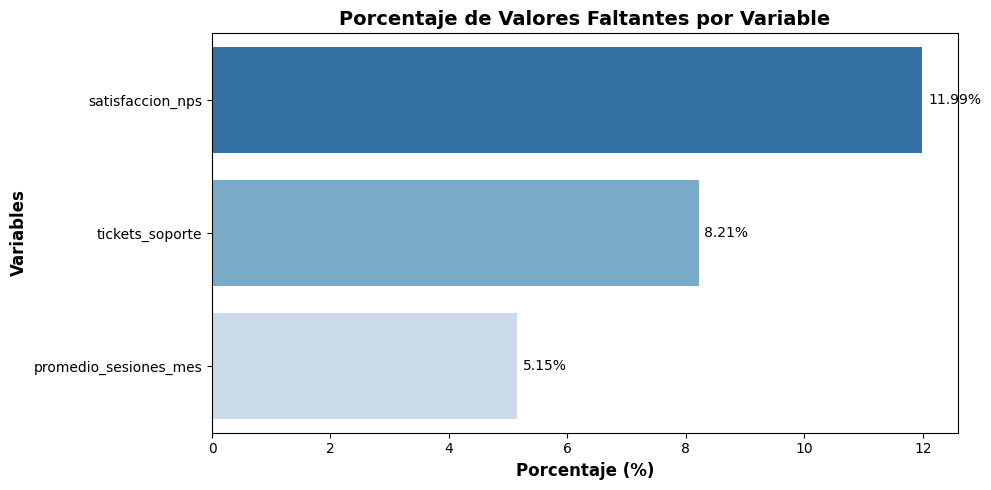

In [ ]:
# 1. Calcular el porcentaje de nulos por columna
porcentaje_nulos = (data.isnull().sum() / len(data)) * 100

# 2. Filtrar solo las que tienen nulos y ordenarlas de mayor a menor
porcentaje_nulos = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)

# 3. Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=porcentaje_nulos.values, y=porcentaje_nulos.index,
hue=porcentaje_nulos.index, palette="Blues_r", legend=False)

# 4. Configuraciones visuales (títulos y etiquetas)
plt.title("Porcentaje de Valores Faltantes por Variable", fontsize=14, fontweight="bold")
plt.xlabel("Porcentaje (%)", fontsize=12, fontweight="bold")
plt.ylabel("Variables", fontsize=12, fontweight="bold")

# 5. Agregar el valor numérico al final de cada barra
for i, v in enumerate(porcentaje_nulos.values):
  ax.text(v + 0.1, i, f"{v:.2f}%", color="black", va="center")

plt.tight_layout()
plt.show()

### Análisis de Valores Faltantes
El gráfico muestra que solo **3 de las 11 variables** presentan datos nulos, todas ellas numéricas y relacionadas con el comportamiento del cliente:
* **`satisfaccion_nps` (11,99%):** es la variable con mayor ausencia; cerca de 1 de cada 8 clientes no respondió la encuesta de satisfacción.
* **`tickets_soporte` (8,21%):** una parte de los clientes no tiene registrado el conteo de tickets de los últimos 6 meses.
* **`promedio_sesiones_mes` (5,15%):** es la variable con menor proporción de nulos.
Las variables de perfil y contrato (`sector_empresa`, `tamano_empresa`, `duracion_contrato`, `pago_puntual`, `gasto_mkt_asociado`) y la variable
objetivo (`mrr_proximo_trimestre`) están completas. Si se eliminaran las filas con al menos un nulo se perderían **7.039 clientes (23,46% del
dataset)**, como se calcula en la celda siguiente, por lo que se justifica técnicamente **imputar** los valores faltantes en lugar de eliminar
registros, conservando la mayor cantidad de información útil para el modelo.


## Tipos de datos inconsistentes



In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB


In [ ]:
# 1. Revisión de la fecha: está almacenada como texto (object) y no como fecha
print("Tipo de dato de fecha_registro:", data["fecha_registro"].dtype)
print("Ejemplos:", data["fecha_registro"].head(3).tolist())

# 2. Verificar que todas las fechas se puedan convertir correctamente
fechas_convertidas = pd.to_datetime(data["fecha_registro"], errors="coerce")
print(f"\nFechas no convertibles: {fechas_convertidas.isnull().sum()}")
print(f"Rango de fechas: {fechas_convertidas.min().date()} a {fechas_convertidas.max().date()}")

# 3. Revisión de variables numéricas que deberían ser enteras
for col in ["tickets_soporte", "satisfaccion_nps"]:
  valores = data[col].dropna()
  print(f"\n{col}: tipo {data[col].dtype} | ¿todos los valores son enteros? {(valores % 1 == 0).all()}")


Tipo de dato de fecha_registro: object
Ejemplos: ['2025-09-14 00:24:49.009633632', '2024-02-12 19:17:24.874829152', '2021-02-03 13:56:48.713623787']

Fechas no convertibles: 0
Rango de fechas: 2021-01-01 a 2025-12-31

tickets_soporte: tipo float64 | ¿todos los valores son enteros? True

satisfaccion_nps: tipo float64 | ¿todos los valores son enteros? True


In [ ]:
# 4. Revisión de las categorías de texto (sin codificar)
columnas_categoricas = ["sector_empresa", "tamano_empresa", "duracion_contrato", "pago_puntual"]
for col in columnas_categoricas:
  categorias = data[col].unique()
  # Verificamos si existen variaciones por espacios o mayúsculas/minúsculas
  categorias_normalizadas = data[col].str.strip().str.lower().unique()
  print(f"{col}: {list(categorias)}")
  print(f" Categorías únicas: {len(categorias)} | Tras normalizar texto: {len(categorias_normalizadas)}\n")


sector_empresa: ['Finanzas', 'Tecnologia', 'Educacion', 'Salud', 'Retail']
 Categorías únicas: 5 | Tras normalizar texto: 5

tamano_empresa: ['Mediana', 'Pequeña', 'Grande']
 Categorías únicas: 3 | Tras normalizar texto: 3

duracion_contrato: ['Mensual', '2 Años', 'Anual']
 Categorías únicas: 3 | Tras normalizar texto: 3

pago_puntual: ['Si', 'No']
 Categorías únicas: 2 | Tras normalizar texto: 2



### Análisis de Tipos de Datos
La inspección de tipos permite identificar las siguientes inconsistencias que deben tratarse antes del modelado:
* **Fecha en formato texto:** `fecha_registro` está almacenada como `object` (texto) e incluye horas con nanosegundos (ej. `2025-09-14
00:24:49.009633632`). Todas las fechas son convertibles (0 errores) y abarcan desde el **01-01-2021 hasta el 31-12-2025**. Un modelo de regresión no
puede utilizar texto, por lo que se transformará en una variable numérica de **antigüedad del cliente en días** (`antiguedad_dias`).
* **Enteros almacenados como flotantes:** `tickets_soporte` y `satisfaccion_nps` son conceptualmente enteros, pero pandas los carga como `float64`
debido a la presencia de valores nulos (`NaN` es un valor flotante). Todos sus valores observados son enteros, por lo que no existe un error de
digitación, solo un efecto de los nulos.
* **Categóricas no codificadas:** `sector_empresa`, `tamano_empresa`, `duracion_contrato` y `pago_puntual` están en formato texto. La Regresión Lineal
solo trabaja con números, por lo que deben codificarse según su naturaleza (ordinal, nominal o binaria).
* **Consistencia del texto:** a diferencia de la entrega anterior, las categorías no presentan variaciones por mayúsculas o espacios (la cantidad de
categorías es la misma antes y después de normalizar), por lo que no se requiere estandarización de texto. Se observa que las categorías vienen sin
tildes (`Tecnologia`, `Educacion`) y que `2 Años` sí contiene la letra ñ, lo que se considera al momento de mapear.


## Sesgo y detección de valores atípicos (Outliers)


### Medidas estadísticas y de dispersión


In [ ]:
# Variables numéricas a analizar (se incluye la variable objetivo solo con fines de diagnóstico)
numeric_cols = ["tickets_soporte", "promedio_sesiones_mes", "satisfaccion_nps",
"gasto_mkt_asociado", "mrr_proximo_trimestre"]
resumen = data[numeric_cols].describe().T
resumen["coef_variacion_%"] = (resumen["std"] / resumen["mean"]) * 100
resumen["asimetria (skew)"] = data[numeric_cols].skew()
resumen.round(2)


,count,mean,std,min,25%,50%,75%,max,coef_variacion_%,asimetria (skew)
tickets_soporte,27536.0,3.01,1.73,0.00,2.00,3.00,4.00,12.00,57.71,0.57
promedio_sesiones_mes,28455.0,50.13,45.06,5.00,18.09,36.23,67.45,430.70,89.88,1.97
satisfaccion_nps,26403.0,5.91,2.31,1.00,4.00,6.00,8.00,10.00,39.10,-0.42
gasto_mkt_asociado,30000.0,2551.09,1416.11,100.36,1330.53,2541.07,3785.67,4999.95,55.51,0.00
mrr_proximo_trimestre,30000.0,710.93,337.69,50.00,458.98,642.60,896.70,3200.04,47.50,1.05


### Análisis de Medidas de Dispersión y Asimetría
* **`promedio_sesiones_mes`** es la variable más problemática: su media (50,13) es muy superior a su mediana (36,23), tiene un coeficiente de
variación cercano al 90% y una asimetría de **1,97** (sesgo fuerte a la derecha). Su máximo (430,7 sesiones) está muy alejado del tercer cuartil
(67,45), lo que anticipa valores atípicos.
* **`mrr_proximo_trimestre`** (variable objetivo) también presenta sesgo positivo (asimetría **1,05**): la mayoría de los clientes genera ingresos
moderados (mediana 642,6 USD) y unos pocos clientes generan ingresos muy altos (hasta 3.200 USD).
* **`tickets_soporte`** tiene un sesgo positivo leve (0,57) y **`satisfaccion_nps`** un sesgo negativo leve (-0,42), ambos dentro de rangos lógicos (0
a 12 tickets y NPS de 1 a 10).
* **`gasto_mkt_asociado`** es prácticamente simétrica (asimetría 0,00), con media y mediana casi idénticas, y valores entre 100 y 5.000 USD, lo que
sugiere una distribución uniforme.
* No se detectan valores negativos ni fuera de rango lógico en ninguna variable.


### Diagramas de caja (Boxplots)


In [ ]:
def diagnostico_outliers_iqr(dataframe: pd.DataFrame, columna: str):
    '''
    Diagnóstico de valores atípicos mediante el Rango Intercuartílico (IQR)
    Parámetros
    ----------
    dataframe: pd.DataFrame
    Set de datos a analizar
    columna: str
    Nombre de la columna a analizar
    Retorna
    -------
    outliers: pd.DataFrame
    Registros atípicos encontrados
    '''
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Aislamiento de registros atípicos
    outliers = dataframe[
        (dataframe[columna] < lower_bound) | (dataframe[columna] > upper_bound)
    ]

    print(f"--- Análisis IQR para la variable '{columna}' ---")
    print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"Límite Inferior: {lower_bound:.2f} | Límite Superior: {upper_bound:.2f}")
    print(f"Registros fuera de límites: {len(outliers)} ({(len(outliers)/len(dataframe))*100:.2f}%)")

    return outliers


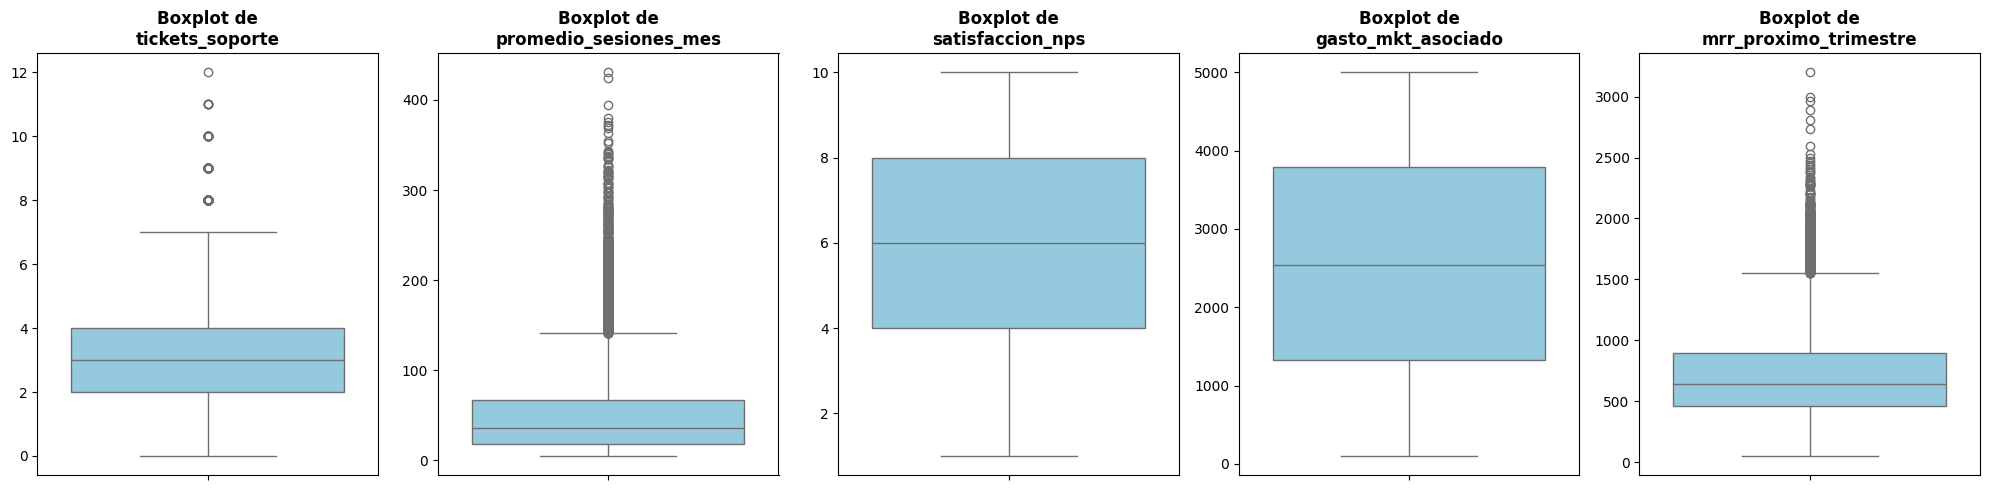

In [ ]:
# 1. Crear la figura (1 fila, cantidad de columnas según variables)
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 5))

# 2. Graficar automáticamente cada variable en su respectivo espacio
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=data[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot de\n{col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("")

# Fuera del bucle for:
plt.tight_layout()
plt.show()


### Análisis de Valores Atípicos (Boxplots)
La evaluación visual de los diagramas de caja revela los siguientes hallazgos:
* **`promedio_sesiones_mes`:** presenta una gran cantidad de valores atípicos por sobre el bigote superior, llegando a más de 400 sesiones mensuales.
Estos clientes de uso intensivo son reales (no son errores), pero pueden distorsionar la media y la escala. Esto justifica usar la **mediana** para
imputar sus nulos y aplicar **`RobustScaler`** en su escalado.
* **`mrr_proximo_trimestre`:** muestra atípicos en la parte alta (clientes que generan más de ~1.550 USD). Al ser la variable objetivo, **no se
modifica**: estos clientes de alto valor son justamente los más importantes para el negocio.
* **`tickets_soporte`:** tiene algunos atípicos puntuales (clientes con 8 o más tickets), que representan clientes con muchos problemas y son
información valiosa para el modelo.
* **`satisfaccion_nps` y `gasto_mkt_asociado`:** no presentan valores atípicos; sus cajas son amplias y simétricas.


In [ ]:
# Detección de outliers para todas las variables numéricas del dataset
outliers_tickets = diagnostico_outliers_iqr(data, "tickets_soporte")
outliers_sesiones = diagnostico_outliers_iqr(data, "promedio_sesiones_mes")
outliers_nps = diagnostico_outliers_iqr(data, "satisfaccion_nps")
outliers_gasto = diagnostico_outliers_iqr(data, "gasto_mkt_asociado")
outliers_mrr = diagnostico_outliers_iqr(data, "mrr_proximo_trimestre")


--- Análisis IQR para la variable 'tickets_soporte' ---
Q1: 2.00 | Q3: 4.00 | IQR: 2.00
Límite Inferior: -1.00 | Límite Superior: 7.00
Registros fuera de límites: 328 (1.09%)
--- Análisis IQR para la variable 'promedio_sesiones_mes' ---
Q1: 18.09 | Q3: 67.45 | IQR: 49.36
Límite Inferior: -55.96 | Límite Superior: 141.50
Registros fuera de límites: 1367 (4.56%)
--- Análisis IQR para la variable 'satisfaccion_nps' ---
Q1: 4.00 | Q3: 8.00 | IQR: 4.00
Límite Inferior: -2.00 | Límite Superior: 14.00
Registros fuera de límites: 0 (0.00%)
--- Análisis IQR para la variable 'gasto_mkt_asociado' ---
Q1: 1330.53 | Q3: 3785.67 | IQR: 2455.14
Límite Inferior: -2352.19 | Límite Superior: 7468.38
Registros fuera de límites: 0 (0.00%)
--- Análisis IQR para la variable 'mrr_proximo_trimestre' ---
Q1: 458.99 | Q3: 896.71 | IQR: 437.72
Límite Inferior: -197.60 | Límite Superior: 1553.29
Registros fuera de límites: 607 (2.02%)


### Resumen cuantitativo de Outliers (Método IQR)

| Variable | Límite superior | Registros atípicos | % del dataset | Decisión |
|---|---:|---:|---:|---|
| `tickets_soporte` | 7,00 | 328 | 1,09% | Se conservan (información real de clientes con problemas) |
| `promedio_sesiones_mes` | 141,50 | 1.367 | 4,56% | Se conservan y se tratan con `RobustScaler` |
| `satisfaccion_nps` | 14,00 | 0 | 0,00% | Sin tratamiento |
| `gasto_mkt_asociado` | 7.468,38 | 0 | 0,00% | Sin tratamiento |
| `mrr_proximo_trimestre` | 1.553,29 | 607 | 2,02% | No se modifica (variable objetivo) |

No se eliminan registros atípicos porque corresponden a comportamientos posibles del negocio (clientes grandes o de uso intensivo) y eliminarlos haría que el modelo no aprenda a predecir justamente a los clientes de mayor valor.


# Fase 2: Limpieza y Tratamiento de Datos (Preprocesamiento e Ingeniería de Características)
**Estrategia contra el Data Leakage:** en esta fase se distinguen dos tipos de transformaciones:
* **Transformaciones deterministas** (no aprenden nada de los datos): convertir la fecha en antigüedad y mapear textos a números con un diccionario fijo. Se pueden aplicar sobre todo el dataset sin riesgo de fuga de información.
* **Transformaciones que aprenden parámetros** (mediana, moda, media, desviación estándar, IQR): la imputación y el escalado. Estas **solo se
definen** en esta fase dentro de un `Pipeline`, y se ajustarán (`fit`) **exclusivamente con el conjunto de entrenamiento** en la Fase 3, después de
dividir los datos.


## Ingeniería de Características: antigüedad del cliente


In [ ]:
data_modelo = data.copy()
# 1. Convertir la fecha de texto a formato fecha
data_modelo["fecha_registro"] = pd.to_datetime(data_modelo["fecha_registro"])
# 2. Fecha de referencia fija: 01-01-2026 (día siguiente al último registro del dataset,
# inicio del trimestre a proyectar). Al ser una constante, no genera fuga de datos.
FECHA_REFERENCIA = pd.Timestamp("2026-01-01")
# 3. Calcular la antigüedad del cliente en días
data_modelo["antiguedad_dias"] = (FECHA_REFERENCIA - data_modelo["fecha_registro"]).dt.days
data_modelo[["fecha_registro", "antiguedad_dias"]].head()

,fecha_registro,antiguedad_dias
0,2025-09-14 00:24:49.009633632,108
1,2024-02-12 19:17:24.874829152,688
2,2021-02-03 13:56:48.713623787,1792
3,2021-08-19 03:21:50.803693456,1595
4,2021-09-26 05:21:16.482549416,1557


In [ ]:
data_modelo["antiguedad_dias"].describe().round(2)


,antiguedad_dias
count,30000.00
mean,913.00
std,526.86
min,1.00
25%,457.00
50%,913.00
75%,1369.00
max,1826.00


### Análisis de la variable `antiguedad_dias`
La fecha de registro se transformó en la cantidad de **días transcurridos entre el alta del cliente y el 01-01-2026** (fecha de inicio del trimestre a
proyectar). Se utilizó una fecha fija y no la fecha actual del sistema para que el resultado sea **reproducible** cada vez que se ejecute el notebook.
La nueva variable toma valores entre 1 y 1.826 días (clientes registrados entre 2021 y 2025) y reemplaza a la fecha en texto, que el modelo de regresión
no puede utilizar.


## Mapeo de variables `duracion_contrato` y `pago_puntual`

In [ ]:
# duracion_contrato: tiene una jerarquía de compromiso (Mensual < Anual < 2 Años)
mapa_contrato = {"Mensual": 0, "Anual": 1, "2 Años": 2}
# pago_puntual: variable binaria
mapa_pago = {"No": 0, "Si": 1}
data_modelo["duracion_contrato"] = data_modelo["duracion_contrato"].map(mapa_contrato)
data_modelo["pago_puntual"] = data_modelo["pago_puntual"].map(mapa_pago)
# Verificación: no deben aparecer nulos por categorías no mapeadas
print("Nulos tras mapear duracion_contrato:", data_modelo["duracion_contrato"].isnull().sum())
print("Nulos tras mapear pago_puntual:", data_modelo["pago_puntual"].isnull().sum())
print()
print(data_modelo["duracion_contrato"].value_counts().sort_index())
print(data_modelo["pago_puntual"].value_counts().sort_index())

Nulos tras mapear duracion_contrato: 0
Nulos tras mapear pago_puntual: 0

duracion_contrato
0    18087
1     8895
2     3018
Name: count, dtype: int64
pago_puntual
0     5912
1    24088
Name: count, dtype: int64


### Justificación del mapeo
* **`duracion_contrato` → 0 / 1 / 2:** se mapea de forma ordinal (Mensual = 0, Anual = 1, 2 Años = 2) porque existe una jerarquía natural en el nivel
de compromiso del contrato.
* **`pago_puntual` → 0 / 1:** al ser binaria, se codifica como No = 0 y Si = 1. El coeficiente del modelo se podrá leer directamente como "cuántos USD
más genera un cliente que paga a tiempo".
Ambos mapeos utilizan diccionarios fijos que no dependen de los datos, por lo que no generan fuga de información.


## Definición de variables dependiente (y) e independientes (X)


In [ ]:
# 1. Eliminar el identificador y la fecha original (ya transformada en antiguedad_dias) de las características (X)
X = data_modelo.drop(columns=["id_cliente", "fecha_registro", "mrr_proximo_trimestre"])
# 2. Variable objetivo a predecir
y = data_modelo["mrr_proximo_trimestre"]
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
X.head()


Dimensiones de X: (30000, 9)
Dimensiones de y: (30000,)


,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,antiguedad_dias
0,Finanzas,Mediana,3.0,34.350838,7.0,0,3932.341944,1,108
1,Tecnologia,Mediana,NaN,28.685569,8.0,0,2547.833298,0,688
2,Tecnologia,Pequeña,5.0,50.027033,7.0,2,3203.232664,1,1792
3,Educacion,Pequeña,0.0,NaN,9.0,1,603.209270,0,1595
4,Educacion,Grande,3.0,NaN,8.0,1,864.788600,1,1557


## Definición de Sub-Pipelines por Tipo de Variable


In [ ]:
# A. Variable continua con sesgo fuerte y outliers -> imputación con MEDIANA + RobustScaler
num_robust_features = ["promedio_sesiones_mes"]
num_robust_pipeline = Pipeline(
steps=[
("imputer", SimpleImputer(strategy="median")), # Rellena nulos con la mediana
("scaler", RobustScaler()), # Escalador resistente a outliers (usa IQR)
]
)
# B. Variables discretas (conteos y puntajes enteros) -> imputación con la MODA + StandardScaler
num_modal_features = ["tickets_soporte", "satisfaccion_nps"]
num_modal_pipeline = Pipeline(
steps=[
("imputer", SimpleImputer(strategy="most_frequent")), # Rellena nulos con el valor modal
("scaler", StandardScaler()), # Escalado estándar (Z-score)
]
)
# C. Variables continuas sin nulos ni outliers -> StandardScaler
num_standard_features = ["gasto_mkt_asociado", "antiguedad_dias"]
num_standard_pipeline = Pipeline(
steps=[
("scaler", StandardScaler()),
]
)
# D. Variable categórica ORDINAL -> Ordinal Encoding respetando la jerarquía
ordinal_features = ["tamano_empresa"]
ordinal_pipeline = Pipeline(
steps=[
("imputer", SimpleImputer(strategy="most_frequent")),
("encoder", OrdinalEncoder(categories=[["Pequeña", "Mediana", "Grande"]])), # 0, 1, 2
]
)
# E. Variable categórica NOMINAL -> One-Hot Encoding
nominal_features = ["sector_empresa"]
nominal_pipeline = Pipeline(
steps=[
("imputer", SimpleImputer(strategy="most_frequent")),
# drop="first" elimina una categoría de referencia para evitar la "trampa de las variables dummy"
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
]
)
# F. Variables ya mapeadas a número (duracion_contrato 0/1/2 y pago_puntual 0/1) -> se mantienen
mapped_features = ["duracion_contrato", "pago_puntual"]
# Integración con ColumnTransformer
preprocessor = ColumnTransformer(
transformers=[
("num_robust", num_robust_pipeline, num_robust_features),
("num_modal", num_modal_pipeline, num_modal_features),
("num_standard", num_standard_pipeline, num_standard_features),
("ordinal", ordinal_pipeline, ordinal_features),
("nominal", nominal_pipeline, nominal_features),
("mapped", "passthrough", mapped_features),
],
remainder="drop",
)


In [ ]:
preprocessor


ColumnTransformer(transformers=[('num_robust',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['promedio_sesiones_mes']),
                                ('num_modal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('scaler', StandardScaler())]),
                                 ['tickets_soporte', 'satisfaccion_nps']),
                                ('num_standard',
                                 Pipeline(steps=[('sca...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['Pequeña',
                                                                              'Mediana',
                                                                              'Grande']]))]),
                                 ['tamano_empresa']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['sector_empresa']),
                                ('mapped', 'passthrough',
                                 ['duracion_contrato', 'pago_puntual'])])

# Tratamiento de los Datos: Estrategias y Justificaciones
A continuación se detallan y fundamentan las decisiones tomadas para la preparación del dataset:
* **Tratamiento de nulos:**
* *`promedio_sesiones_mes` (5,15% nulos) → **Mediana**.* *Justificación:* es una variable continua con sesgo fuerte (asimetría 1,97) y 4,56% de
outliers; la media está "inflada" por los clientes de uso intensivo (50,13 vs. mediana 36,23), por lo que la mediana representa mejor al cliente típico.
* *`tickets_soporte` (8,21%) y `satisfaccion_nps` (11,99%) → **Valor modal**.* *Justificación:* son variables discretas enteras (conteos y
puntajes de 1 a 10). La moda mantiene valores válidos del dominio (3 tickets y NPS 7) y evita crear valores decimales sin sentido de negocio.
* **Ingeniería de características:** `fecha_registro` se transformó en `antiguedad_dias` (días desde el alta hasta el 01-01-2026).
* **Codificación categórica:**
* *Ordinal Encoding* para `tamano_empresa` (Pequeña = 0, Mediana = 1, Grande = 2), porque existe una jerarquía natural de tamaño.
* *One-Hot Encoding* para `sector_empresa`, porque es nominal (no existe un orden entre sectores). Se usa `drop="first"`, dejando **Educacion**
como categoría de referencia para evitar multicolinealidad perfecta en la regresión.
* *Mapeo numérico/binario* para `duracion_contrato` (0/1/2) y `pago_puntual` (0/1).
* **Escalado de variables:**
* *`RobustScaler`* para `promedio_sesiones_mes`, porque utiliza la mediana y el IQR, que no se ven afectados por los valores extremos.
* *`StandardScaler`* para `tickets_soporte`, `satisfaccion_nps`, `gasto_mkt_asociado` y `antiguedad_dias`, que no presentan outliers severos.
* Las variables codificadas (0/1/2 y dummies) no se escalan para mantener su interpretación directa en USD por nivel o por categoría.
* **Outliers:** no se eliminan registros, ya que representan clientes reales (grandes o de uso intensivo); su efecto se controla con `RobustScaler`.
* **Data Leakage:** todos los parámetros aprendidos (mediana, moda, media, desviación estándar, IQR) se calculan **solo con el conjunto de
entrenamiento** gracias al uso de `Pipeline` + `ColumnTransformer`.


# Fase 3: Construcción del Modelo (Entrenamiento)

## División en conjuntos de entrenamiento y prueba

In [ ]:
# División en Train / Test ANTES de ajustar cualquier transformación (Paso clave contra Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
print(f"Dataset de Entrenamiento (X_train): {X_train.shape}")
print(f"Dataset de Prueba (X_test): {X_test.shape}")
print(f"\nMRR promedio en Train: {y_train.mean():.2f} USD | MRR promedio en Test: {y_test.mean():.2f} USD")

Dataset de Entrenamiento (X_train): (24000, 9)
Dataset de Prueba (X_test): (6000, 9)

MRR promedio en Train: 711.58 USD | MRR promedio en Test: 708.31 USD


### Justificación de la división
Se reserva el **80% de los datos (24.000 clientes) para entrenamiento** y el **20% (6.000 clientes) para prueba**, con `random_state=42` para que la
división sea reproducible. El conjunto de prueba representa a "clientes nuevos" que el modelo nunca vio, lo que permite medir su desempeño real. El MRR
promedio es similar en ambos conjuntos, lo que confirma que la división es representativa.


## Ajuste del preprocesamiento (Zero Data Leakage)


In [ ]:
# 1. Fit y Transform SOLO sobre el conjunto de Entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)
# 2. Transform (NUNCA FIT) sobre el conjunto de Prueba
X_test_processed = preprocessor.transform(X_test)
# 3. Obtener los nombres de las columnas finales
feature_names = [nombre.split("__")[1] for nombre in preprocessor.get_feature_names_out()]
X_train_prep = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_prep = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)
display(X_train_prep.head(3).round(3))


,promedio_sesiones_mes,tickets_soporte,satisfaccion_nps,gasto_mkt_asociado,antiguedad_dias,tamano_empresa,sector_empresa_Finanzas,sector_empresa_Retail,sector_empresa_Salud,sector_empresa_Tecnologia,duracion_contrato,pago_puntual
21753,1.087,-1.198,0.435,-0.833,1.510,1.0,0.0,0.0,0.0,1.0,1.0,1.0
251,1.009,-1.797,-0.020,1.537,0.984,1.0,0.0,0.0,0.0,1.0,0.0,0.0
22941,-0.569,-1.198,0.890,-1.473,-1.735,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Entrenamiento del modelo de Regresión Lineal


In [ ]:
# Pipeline completo: preprocesamiento + modelo
modelo = Pipeline(
steps=[
("preprocessor", preprocessor),
("regresion", LinearRegression()),
]
)
# Entrenamiento SOLO con el conjunto de entrenamiento
modelo.fit(X_train, y_train)
print("Modelo de Regresión Lineal entrenado correctamente.")
print(f"Intercepto (β0): {modelo.named_steps['regresion'].intercept_:.2f} USD")


Modelo de Regresión Lineal entrenado correctamente.
Intercepto (β0): 218.32 USD


# Fase 4: Evaluación e Interpretación de Métricas


## Cálculo de métricas sobre el conjunto de prueba


In [ ]:
# 1. Predicciones sobre el conjunto de prueba (datos nunca vistos por el modelo)
y_pred_test = modelo.predict(X_test)
# 2. Métricas de desempeño solicitadas
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
print("=== MÉTRICAS DEL MODELO (CONJUNTO DE PRUEBA) ===")
print(f"• Coeficiente de Determinación (R²): {r2_test:.4f} -> {r2_test * 100:.2f}% de la varianza explicada")
print(f"• Error Absoluto Medio (MAE): {mae_test:.2f} USD")


=== MÉTRICAS DEL MODELO (CONJUNTO DE PRUEBA) ===
• Coeficiente de Determinación (R²): 0.9240 -> 92.40% de la varianza explicada
• Error Absoluto Medio (MAE): 68.32 USD


# Interpretación de las Métricas en el Contexto Financiero de SaaSFlow
### Coeficiente de Determinación (R² ≈ 0,92)
El modelo explica aproximadamente el **92% de la variabilidad** del ingreso mensual recurrente del próximo trimestre entre clientes. En términos de
negocio, esto significa que las diferencias de ingreso entre un cliente y otro se explican casi completamente por su tamaño, su uso de la plataforma, su
tipo de contrato, su comportamiento de pago y su satisfacción. Solo cerca de un 8% de la variación depende de factores que el modelo no captura, por lo
que la herramienta es confiable para la proyección de ingresos.
### Error Absoluto Medio (MAE ≈ 68 USD)
**El modelo se equivoca en promedio en aproximadamente 68 USD por cliente** al estimar su MRR mensual. Considerando que el MRR promedio de la cartera es
de ~711 USD (Fase 1), el error típico equivale a cerca de un **10% del ingreso de un cliente**.
Para la dirección comercial, esto se traduce en:
* Una **proyección de ingresos confiable** para la planificación financiera trimestral.
* La capacidad de **identificar con anticipación a los clientes cuyo MRR proyectado es bajo**, para que Customer Success intervenga antes de que se
produzca la fuga de ingresos.
